In [1]:
from _Aplha_n_methods import Alpha_N_calc as an
from _Aplha_n_methods import init_worker
from _Geometry_methods import Geometry_helper as gh
from _Prettyplt import PrettyPlot as pp

import openmc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import os


import openmc.deplete as dep
import time
from collections import defaultdict #To use dictionaries to remove dublicates

os.system("rm model.xml")

rm: cannot remove 'model.xml': No such file or directory


256

In [2]:
#Setting geometry and materials
#Geometry
new_geom = True
fuel_name="Fuel_CA_2" 


if new_geom:
    #Reactor geometry parameters
    inner_fuel_r = 55
    outer_fuel_r = 65
    outer_moderater_r = 80
    blanket_or = 100
    
    #Control for readtor
    inner_moderator_height = 95
    
    materials = gh.create_materials(fuel_name)
    geom, materials= gh.set_geom_fuel_shell(inner_fuel_r, outer_fuel_r, outer_moderater_r,
                                            with_blanket=True, blanket_or=blanket_or, 
                                            inner_moderator_height=inner_moderator_height, 
                                            materials=materials, fuel_name=fuel_name)
else:
    openmc.reset_auto_ids()
    geom = openmc.Geometry.from_xml("geometry.xml")
    materials= openmc.Materials.from_xml('materials.xml')
fuel = gh.get_material_by_name(fuel_name,materials)


Materials defined: 
Fuel_CA_2
Blanket_CA
d2o
Air


SRIM perfekt threshold was not found using 7 isotopes
Writing SRIM file after 101 threshold tries
len target elements 7, #elements 7
SRModule done, length of data: 71 and 71
Getting cross sections...
Making kernels and integrent...


/openmc_venv/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=1.
  warn(msg, IDWarning)


setup done in 3.219142093032133 s
n_per_s_per_kg:  189.05534972781075


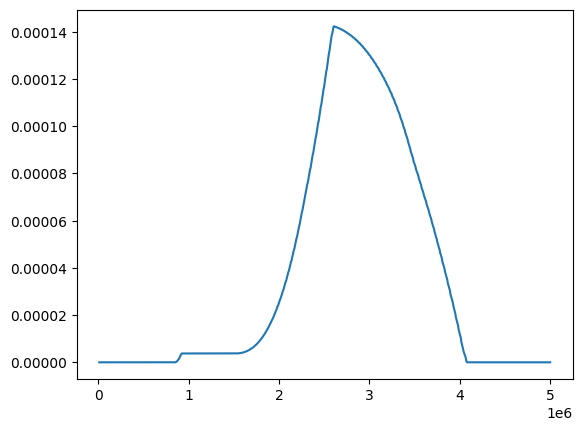

In [3]:
neutron_intensities,neutron_energies,n_per_s_per_kg = an.neutron_spectra_from_material(fuel,E_min=1e4,nr_points=1000,nr_energies=1000,new_file=False)
neutron_intensities = np.clip(neutron_intensities,0,None)
energy = openmc.stats.Tabular(neutron_energies, neutron_intensities)

fig,ax =plt.subplots()

ax.plot(neutron_energies,neutron_intensities)

print('n_per_s_per_kg: ',n_per_s_per_kg)

In [4]:
def shell_vol_calc(geom_or,geom_ir):
    volume=4/3*np.pi*(geom_or**3-geom_ir**3)
    return volume

fuel_vol = shell_vol_calc(outer_fuel_r,inner_fuel_r)
fuel_mass = fuel.density*fuel_vol/1000 #g/cm^3*cm^3 -> kg

#fuel.volume = fuel_vol

print('fuel_mass',fuel_mass)

total_n_per_s = n_per_s_per_kg*fuel_mass

print('total n production',total_n_per_s)

fuel_mass 2224.1062270721623
total n production 420479.1805909293


In [5]:
inner_fuel_radius = geom.get_surfaces_by_name('fuel_inner')[0].bounding_box('-')[1][0]
outer_fuel_radius = geom.get_surfaces_by_name('fuel_outer')[0].bounding_box('-')[1][0]

inner_blanket_radius = geom.get_surfaces_by_name('blanket_inner')[0].bounding_box('-')[1][0]
outer_blanket_radius = geom.get_surfaces_by_name('blanket_outer')[0].bounding_box('-')[1][0]

fuel_space = openmc.stats.spherical_uniform(r_outer=outer_fuel_radius,r_inner=inner_fuel_radius)
blanket_space = openmc.stats.spherical_uniform(r_outer=outer_blanket_radius,r_inner=inner_blanket_radius)

In [6]:
settings_dep = openmc.Settings()
settings_dep.run_mode =  'fixed source'

#Fixing Li6 at 900 K doesn't have a cross section 
settings_dep.temperature = {
    'method': 'nearest',
    'tolerance': 1000}

settings_dep.batches = 10
settings_dep.inactive = 0
settings_dep.particles = 2000 

#model_dep = openmc.Model(geometry=geom, materials=materials, settings=settings_dep)
def openmcRunDepletion(geom, settings, materials,timestep_units):
    chain_file="chain_endfb71_sfr.xml"
    # Depletion operator
    print('nr of batches',settings.batches,' particles ',settings.particles)
    model_dep = openmc.Model(geometry=geom, materials=materials, settings=settings)
    model_dep.export_to_xml()
    op = dep.CoupledOperator(model_dep,chain_file)
    
    # Take one timestep
    timestep = [1]  # days also only test
    power = 1e6 # watts Needs to be changed, can be excluded?
    
    # Deplete using mid-point predictor-corrector
    cecm = openmc.deplete.CECMIntegrator(
        op, timestep, power, timestep_units=timestep_units)
    cecm.integrate() 

In [7]:
cells = list(geom.get_all_cells().values())
for cell in cells:
    print(cell)
#Tallies
def make_tallies_fission(blanket_orS):
    resolution_of_mesh=10
    mesh_size = int(blanket_or)
    os.system("rm tallies.xml")
        
    # Tally 2: Materials flux
    # Create mesh which will be used for tally
    mesh = openmc.RegularMesh()
    mesh.dimension = [mesh_size*resolution_of_mesh, mesh_size*resolution_of_mesh]
    mesh.lower_left = [-mesh_size, -mesh_size]
    mesh.upper_right = [mesh_size, mesh_size]
    
    # Create mesh filter for tally
    mesh_filter = openmc.MeshFilter(mesh)
    
    t1 = openmc.Tally(1)
    t1.filters = [mesh_filter]
    t1.scores = ["flux","nu-fission","nu-scatter"] 

    # Tally 2: energy spectrum in fuel from fission
    fuel_cell = geom.get_cells_by_name('fuel')[0]
    cell_filter1 = openmc.CellFilter(fuel_cell)
    energybins=np.logspace(-2,7,1001) #1000 bins between 1e-2 eV and 1e7 eV
    energy_filter = openmc.EnergyFilter(energybins)
        
    t2 = openmc.Tally(2)
    t2.filters = [cell_filter1,energy_filter]
    t2.scores = ['nu-fission','nu-scatter']
    
    #implement both tallies
    tallies = openmc.Tallies([t1,t2]) #tallies.append(tally) is also an option
    print(tallies)
    tallies.export_to_xml()
    return tallies
tallies = make_tallies_fission(blanket_or)

Cell
	ID             =	1
	Name           =	fuel
	Fill           =	Material 11
	Region         =	(2 -1)
	Rotation       =	None
	Temperature    =	None
	Translation    =	None
	Volume         =	None

Cell
	ID             =	2
	Name           =	moderator
	Fill           =	Material 1
	Region         =	((-4 -3) | (5 -6))
	Rotation       =	None
	Temperature    =	None
	Translation    =	None
	Volume         =	None

Cell
	ID             =	3
	Name           =	blanket
	Fill           =	Material 10
	Region         =	(6 -7)
	Rotation       =	None
	Temperature    =	None
	Translation    =	None
	Volume         =	None

Cell
	ID             =	4
	Name           =	
	Fill           =	None
	Region         =	(7 -8)
	Rotation       =	None
	Translation    =	None
	Volume         =	None

Cell
	ID             =	5
	Name           =	air
	Fill           =	Material 5
	Region         =	(-4 3)
	Rotation       =	None
	Temperature    =	None
	Translation    =	None
	Volume         =	None

[Tally
	ID             =	1
	Name     

In [8]:
def set_alpha_n_source(material,space,innr_r,outer_r):
    print(f'\n\t{material.name}')
    n_intensities,n_energies,n_per_s_per_kg = an.neutron_spectra_from_material(material,E_min=1e4,
                                                                               nr_points=1000,nr_energies=1000,
                                                                               new_file=True)
    
    n_intensities = np.clip(n_intensities,0,None)
    energy = openmc.stats.Tabular(n_energies, n_intensities)
    
    material_vol = shell_vol_calc(outer_fuel_r,inner_fuel_r)
    material_mass = material.density*material_vol/1000
    total_n_per_s = n_per_s_per_kg*material_mass

    return openmc.IndependentSource(space=space, energy=energy,particle='neutron', strength=total_n_per_s)

date = '230926'
#Settings for depletion
timestep_units = 'h'
seconds_per_time_step = 3600
chain_file="chain_endfb71_sfr.xml"
use_tallies = True

nr_steps = 12
start_i = time.perf_counter()
timings = np.zeros(nr_steps)
src_a_n_fuel_strengths = np.zeros(nr_steps)
src_a_n_blanket_strengths = np.zeros(nr_steps)
src_fission_strengths = np.zeros(nr_steps)
src_scatter_strengths = np.zeros(nr_steps)

#Getting materials
fuel = gh.get_material_by_name(fuel_name,materials)
blanket = gh.get_material_by_name('Blanket_CA',materials)


fuel_cell = geom.get_all_cells()[1]
blanket_cell = geom.get_all_cells()[3]

#Saving density to be used when openmc loose track
fuel_density = fuel.density
blanket_density = blanket.density

blanket_vol = blanket.volume
fuel_vol = fuel.volume

fission_src_strength = 0
fission_energy = energy = openmc.stats.Tabular([0],[0])

scatter_src_strength = 0
scatter_energy = energy = openmc.stats.Tabular([0],[0])

print(f'nr of batches',settings_dep.batches,' particles ',settings_dep.particles)

for step in range(nr_steps):
    #Setting alpha,n sources
    fuel_src = set_alpha_n_source(fuel,fuel_space,inner_fuel_radius,outer_fuel_radius)
    blanket_src = set_alpha_n_source(blanket,blanket_space,inner_blanket_radius,outer_blanket_radius)

    fission_src = openmc.IndependentSource(space=fuel_space, energy=fission_energy,
                                           particle='neutron', strength=fission_src_strength)
    scatter_src = openmc.IndependentSource(space=fuel_space, energy=scatter_energy,
                                           particle='neutron', strength=scatter_src_strength)

    src_a_n_fuel_strengths[step] = fuel_src.strength
    src_a_n_blanket_strengths[step] = blanket_src.strength
    src_fission_strengths[step] = fission_src.strength
    src_scatter_strengths[step] = scatter_src.strength

    data_to_file = np.column_stack((src_a_n_fuel_strengths,src_a_n_blanket_strengths,src_fission_strengths,src_scatter_strengths))
    np.savetxt(f'src_strengths_{date}_time_{nr_steps}_{timestep_units}.csv',data_to_file,delimiter=",",
           header='src_a_n_fuel_strengths,src_a_n_blanket_strengths,src_fission_strengths,src_scatter_strength')
    
    settings_dep.source = [fuel_src,blanket_src,fission_src,scatter_src]
    
    
    # Depletion operator

    if use_tallies:
        model_dep = openmc.Model(geometry=geom, materials=materials, settings=settings_dep,tallies=tallies)
    else:
        model_dep = openmc.Model(geometry=geom, materials=materials, settings=settings_dep)
    model_dep.export_to_xml()
    op = dep.CoupledOperator(model_dep,chain_file)
    
    # Take one timestep
    timestep = [1]  

    source_rate_total = fuel_src.strength + blanket_src.strength + fission_src.strength + scatter_src.strength
    
    # Deplete using mid-point predictor-corrector
    #os.system("rm summary.h5")
    pInt = openmc.deplete.PredictorIntegrator(op, timestep, source_rates = source_rate_total, 
                                              timestep_units=timestep_units)
    pInt.integrate() 

    #Slower integrater but 2nd order
    #CECM = openmc.deplete.CECMIntegrator(op, timestep, source_rates = source_rate_total, 
                                              #timestep_units=timestep_units)
    #CECM.integrate()

    #timing for loop
    timings[step] = time.perf_counter()-start_i
    print(f'timesteps {timings[step]/60:.3g} min, particles: {settings_dep.particles}')
    print(f'batches: {settings_dep.batches}, source strength: {source_rate_total:.4g}')

    [print(f'step {s}\t time: {time:.3g}') for s,time in zip(range(nr_steps),timings)]
    
    #Getting results
    results = openmc.deplete.Results("depletion_results.h5")
    openmc.reset_auto_ids()
    materials = results.export_to_materials(burnup_index=1)
    materials.export_to_xml(f"{fuel_name}_nr_{step}_{timestep_units}.xml")

    #Setting materials 
    fuel = gh.get_material_by_name(fuel_name,materials)
    blanket = gh.get_material_by_name('Blanket_CA',materials)

    #Filling cells with depleted materials
    fuel_cell.fill = fuel
    blanket_cell.fill = blanket

    #Taking fission from last run
    with openmc.StatePoint(f'statepoint.{settings_dep.batches}.h5') as sp:
        tally = sp.get_tally(id=1)
        tally1 = sp.get_tally(id=2)
    
    fission = tally.get_slice(scores=['nu-fission'])
    scatter = tally.get_slice(scores=['nu-scatter'])
    
    fission_tally = tally1.get_pandas_dataframe(scores=['nu-fission'])
    scatter_tally = tally1.get_pandas_dataframe(scores=['nu-scatter'])
    
    try:
        data_to_file = np.column_stack((fission_tally['energy low [eV]'],fission_tally['mean'],fission_tally['std. dev.']))
        np.savetxt(f'fission_tally_{date}_time_{step}_{timestep_units}.csv',data_to_file,delimiter=",",
                   header='energy,fission mean,fission std_dev')
        data_to_file = np.column_stack((scatter_tally['energy low [eV]'],scatter_tally['mean'],scatter_tally['std. dev.']))
        np.savetxt(f'scatter_tally_{date}_time_{step}_{timestep_units}.csv',data_to_file,delimiter=",",
                   header='energy,scatter mean,scatter std_dev')
    except:
        print('\n=========\ntallies have no std. dev.\n===========\n')
        data_to_file = np.column_stack((fission_tally['energy low [eV]'],fission_tally['mean']))
        np.savetxt(f'fission_tally_{date}_time_{step}_{timestep_units}.csv',data_to_file,delimiter=",",
                   header='energy,fission mean')
        data_to_file = np.column_stack((scatter_tally['energy low [eV]'],scatter_tally['mean']))
        np.savetxt(f'scatter_tally_{date}_time_{step}_{timestep_units}.csv',data_to_file,delimiter=",",
                   header='energy,scatter mean')

    total_fission_n = fission_tally['mean'].sum()
    total_scatter_n = scatter_tally['mean'].sum()
    
    fission_src_strength = total_fission_n/seconds_per_time_step
    scatter_src_strength = total_scatter_n/seconds_per_time_step
    print('seeing if tallies give same number',fission_tally['mean'].sum(),sum(sum(fission.mean)))
    
    fission_energy = openmc.stats.Tabular(fission_tally['energy low [eV]'], fission_tally['mean'])
    scatter_energy = openmc.stats.Tabular(scatter_tally['energy low [eV]'], scatter_tally['mean'])
    
    #Setting density again if missing 
    if fuel.density != None:
        fuel_mass = fuel.density*fuel_vol/1000 #g/cm^3*cm^3 -> kg
        fuel_density = fuel.density
    else:
        print(f'using old density{fuel_density}')
        fuel.set_density('g/cm3', fuel_density)
    
    if blanket.density != None:
        blanket_mass = blanket.density*blanket_vol/1000 #g/cm^3*cm^3 -> kg
        blanket_density = blanket.density
    else:
        print(f'using old density {blanket_density}')
        blanket.set_density('g/cm3', blanket_density)
    
    #Setting start time for next loop
    start_i = time.perf_counter()

nr of batches 10  particles  2000

	Fuel_CA_2
SRIM perfekt threshold was not found using 7 isotopes
Writing SRIM file after 101 threshold tries
len target elements 7, #elements 7
SRModule done, length of data: 71 and 71
Getting cross sections...
Making kernels and integrent...
setup done in 4.185123122995719 s

	Blanket_CA
SRIM perfekt threshold was not found using 5 isotopes
Writing SRIM file after 101 threshold tries
len target elements 5, #elements 5
SRModule done, length of data: 71 and 71
Getting cross sections...
Making kernels and integrent...
setup done in 4.129118480021134 s
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                 

 Reading Th230 from /root/nndc_hdf5/Th230.h5
 Reading Th232 from /root/nndc_hdf5/Th232.h5
 Reading U234 from /root/nndc_hdf5/U234.h5
 Reading U235 from /root/nndc_hdf5/U235.h5
 Reading U236 from /root/nndc_hdf5/U236.h5
 Reading U238 from /root/nndc_hdf5/U238.h5
 Reading c_D_in_D2O from /root/nndc_hdf5/c_D_in_D2O.h5
 Minimum neutron data temperature: 294 K
 Maximum neutron data temperature: 294 K
 Reading tallies XML file...
 Preparing distributed cell instances...
 Reading plot XML file...
 Writing summary.h5 file...
[openmc.deplete] t=0.0 s, dt=3600 s, source=902196.133523039
 Reading H1 from /root/nndc_hdf5/H1.h5
 Reading H3 from /root/nndc_hdf5/H3.h5
 Reading He3 from /root/nndc_hdf5/He3.h5
 Reading He4 from /root/nndc_hdf5/He4.h5
 Reading Be9 from /root/nndc_hdf5/Be9.h5
 Reading B10 from /root/nndc_hdf5/B10.h5
 Reading B11 from /root/nndc_hdf5/B11.h5
 Reading Na22 from /root/nndc_hdf5/Na22.h5
 Reading Na23 from /root/nndc_hdf5/Na23.h5


 Reading Mg24 from /root/nndc_hdf5/Mg24.h5
 Reading Mg25 from /root/nndc_hdf5/Mg25.h5
 Reading Mg26 from /root/nndc_hdf5/Mg26.h5
 Reading Al27 from /root/nndc_hdf5/Al27.h5
 Reading Si28 from /root/nndc_hdf5/Si28.h5
 Reading Si29 from /root/nndc_hdf5/Si29.h5
 Reading Si30 from /root/nndc_hdf5/Si30.h5
 Reading P31 from /root/nndc_hdf5/P31.h5
 Reading S32 from /root/nndc_hdf5/S32.h5
 Reading S33 from /root/nndc_hdf5/S33.h5
 Reading S34 from /root/nndc_hdf5/S34.h5
 Reading S36 from /root/nndc_hdf5/S36.h5
 Reading Cl35 from /root/nndc_hdf5/Cl35.h5
 Reading Cl37 from /root/nndc_hdf5/Cl37.h5
 Reading K39 from /root/nndc_hdf5/K39.h5
 Reading K40 from /root/nndc_hdf5/K40.h5
 Reading K41 from /root/nndc_hdf5/K41.h5
 Reading Ca40 from /root/nndc_hdf5/Ca40.h5
 Reading Ca42 from /root/nndc_hdf5/Ca42.h5
 Reading Ca43 from /root/nndc_hdf5/Ca43.h5
 Reading Ca44 from /root/nndc_hdf5/Ca44.h5
 Reading Ca46 from /root/nndc_hdf5/Ca46.h5
 Reading Ca48 from /root/nndc_hdf5/Ca48.h5
 Reading Sc45 from /root/nn

 Reading Kr83 from /root/nndc_hdf5/Kr83.h5
 Reading Kr84 from /root/nndc_hdf5/Kr84.h5
 Reading Kr85 from /root/nndc_hdf5/Kr85.h5
 Reading Kr86 from /root/nndc_hdf5/Kr86.h5
 Reading Rb85 from /root/nndc_hdf5/Rb85.h5
 Reading Rb86 from /root/nndc_hdf5/Rb86.h5
 Reading Rb87 from /root/nndc_hdf5/Rb87.h5
 Reading Sr84 from /root/nndc_hdf5/Sr84.h5
 Reading Sr86 from /root/nndc_hdf5/Sr86.h5
 Reading Sr87 from /root/nndc_hdf5/Sr87.h5
 Reading Sr88 from /root/nndc_hdf5/Sr88.h5
 Reading Sr89 from /root/nndc_hdf5/Sr89.h5
 Reading Sr90 from /root/nndc_hdf5/Sr90.h5
 Reading Y89 from /root/nndc_hdf5/Y89.h5
 Reading Y90 from /root/nndc_hdf5/Y90.h5
 Reading Y91 from /root/nndc_hdf5/Y91.h5
 Reading Zr90 from /root/nndc_hdf5/Zr90.h5
 Reading Zr91 from /root/nndc_hdf5/Zr91.h5
 Reading Zr92 from /root/nndc_hdf5/Zr92.h5
 Reading Zr93 from /root/nndc_hdf5/Zr93.h5
 Reading Zr94 from /root/nndc_hdf5/Zr94.h5
 Reading Zr95 from /root/nndc_hdf5/Zr95.h5
 Reading Zr96 from /root/nndc_hdf5/Zr96.h5
 Reading Nb93 fro

 Reading Nb95 from /root/nndc_hdf5/Nb95.h5
 Reading Mo92 from /root/nndc_hdf5/Mo92.h5
 Reading Mo94 from /root/nndc_hdf5/Mo94.h5
 Reading Mo95 from /root/nndc_hdf5/Mo95.h5
 Reading Mo96 from /root/nndc_hdf5/Mo96.h5
 Reading Mo97 from /root/nndc_hdf5/Mo97.h5
 Reading Mo98 from /root/nndc_hdf5/Mo98.h5
 Reading Mo99 from /root/nndc_hdf5/Mo99.h5


...

 Reading Xe129 from /root/nndc_hdf5/Xe129.h5
 Reading Xe130 from /root/nndc_hdf5/Xe130.h5
 Reading Xe131 from /root/nndc_hdf5/Xe131.h5
 Reading Xe132 from /root/nndc_hdf5/Xe132.h5
 Reading Xe133 from /root/nndc_hdf5/Xe133.h5
 Reading Xe134 from /root/nndc_hdf5/Xe134.h5
 Reading Xe135 from /root/nndc_hdf5/Xe135.h5
 Reading Xe136 from /root/nndc_hdf5/Xe136.h5
 Reading Cs133 from /root/nndc_hdf5/Cs133.h5
 Reading Cs134 from /root/nndc_hdf5/Cs134.h5
 Reading Cs135 from /root/nndc_hdf5/Cs135.h5
 Reading Cs136 from /root/nndc_hdf5/Cs136.h5
 Reading Cs137 from /root/nndc_hdf5/Cs137.h5
 Reading Ba130 from /root/nndc_hdf5/Ba130.h5
 Reading Ba132 from /root/nndc_hdf5/Ba132.h5
 Reading Ba133 from /root/nndc_hdf5/Ba133.h5


 Reading Ba134 from /root/nndc_hdf5/Ba134.h5
 Reading Ba135 from /root/nndc_hdf5/Ba135.h5
 Reading Ba136 from /root/nndc_hdf5/Ba136.h5
 Reading Ba137 from /root/nndc_hdf5/Ba137.h5
 Reading Ba138 from /root/nndc_hdf5/Ba138.h5
 Reading Ba140 from /root/nndc_hdf5/Ba140.h5
 Reading La138 from /root/nndc_hdf5/La138.h5
 Reading La139 from /root/nndc_hdf5/La139.h5
 Reading La140 from /root/nndc_hdf5/La140.h5
 Reading Ce136 from /root/nndc_hdf5/Ce136.h5
 Reading Ce138 from /root/nndc_hdf5/Ce138.h5
 Reading Ce139 from /root/nndc_hdf5/Ce139.h5
 Reading Ce140 from /root/nndc_hdf5/Ce140.h5
 Reading Ce141 from /root/nndc_hdf5/Ce141.h5
 Reading Ce142 from /root/nndc_hdf5/Ce142.h5
 Reading Ce143 from /root/nndc_hdf5/Ce143.h5
 Reading Ce144 from /root/nndc_hdf5/Ce144.h5
 Reading Pr141 from /root/nndc_hdf5/Pr141.h5
 Reading Pr142 from /root/nndc_hdf5/Pr142.h5
 Reading Pr143 from /root/nndc_hdf5/Pr143.h5
 Reading Nd142 from /root/nndc_hdf5/Nd142.h5
 Reading Nd143 from /root/nndc_hdf5/Nd143.h5
 Reading N

 Reading Gd153 from /root/nndc_hdf5/Gd153.h5
 Reading Gd154 from /root/nndc_hdf5/Gd154.h5
 Reading Gd155 from /root/nndc_hdf5/Gd155.h5
 Reading Gd156 from /root/nndc_hdf5/Gd156.h5
 Reading Gd157 from /root/nndc_hdf5/Gd157.h5
 Reading Gd158 from /root/nndc_hdf5/Gd158.h5
 Reading Gd160 from /root/nndc_hdf5/Gd160.h5
 Reading Tb159 from /root/nndc_hdf5/Tb159.h5
 Reading Tb160 from /root/nndc_hdf5/Tb160.h5
 Reading Dy156 from /root/nndc_hdf5/Dy156.h5
 Reading Dy158 from /root/nndc_hdf5/Dy158.h5
 Reading Dy160 from /root/nndc_hdf5/Dy160.h5
 Reading Dy161 from /root/nndc_hdf5/Dy161.h5
 Reading Dy162 from /root/nndc_hdf5/Dy162.h5
 Reading Dy163 from /root/nndc_hdf5/Dy163.h5
 Reading Dy164 from /root/nndc_hdf5/Dy164.h5
 Reading Ho165 from /root/nndc_hdf5/Ho165.h5
 Reading Ho166_m1 from /root/nndc_hdf5/Ho166_m1.h5
 Reading Er162 from /root/nndc_hdf5/Er162.h5
 Reading Er164 from /root/nndc_hdf5/Er164.h5
 Reading Er166 from /root/nndc_hdf5/Er166.h5
 Reading Er167 from /root/nndc_hdf5/Er167.h5
 Rea

/openmc_venv/lib/python3.11/site-packages/openmc/tallies.py:450: RuntimeWarning: invalid value encountered in sqrt
  self._std_dev[nonzero] = np.sqrt((self.sum_sq[nonzero]/n -


using old density4.905
using old density 4.626


In [9]:
for timestep in timings:
    print(f' Tid: {timestep/60:.3g} min')

 Tid: 124 min
 Tid: 147 min
 Tid: 164 min
 Tid: 174 min
 Tid: 187 min
 Tid: 142 min
 Tid: 163 min
 Tid: 126 min
 Tid: 142 min
 Tid: 99.8 min
 Tid: 107 min
 Tid: 91.4 min


In [10]:
print(fission_tally.columns)
print(scatter_tally.columns)

Index(['cell', 'energy low [eV]', 'energy high [eV]', 'nuclide', 'score',
       'mean', 'std. dev.'],
      dtype='object')
Index(['cell', 'energy low [eV]', 'energy high [eV]', 'nuclide', 'score',
       'mean', 'std. dev.'],
      dtype='object')


/openmc_venv/lib/python3.11/site-packages/openmc/tallies.py:450: RuntimeWarning: invalid value encountered in sqrt
  self._std_dev[nonzero] = np.sqrt((self.sum_sq[nonzero]/n -


total fission tallied 7.612e+08


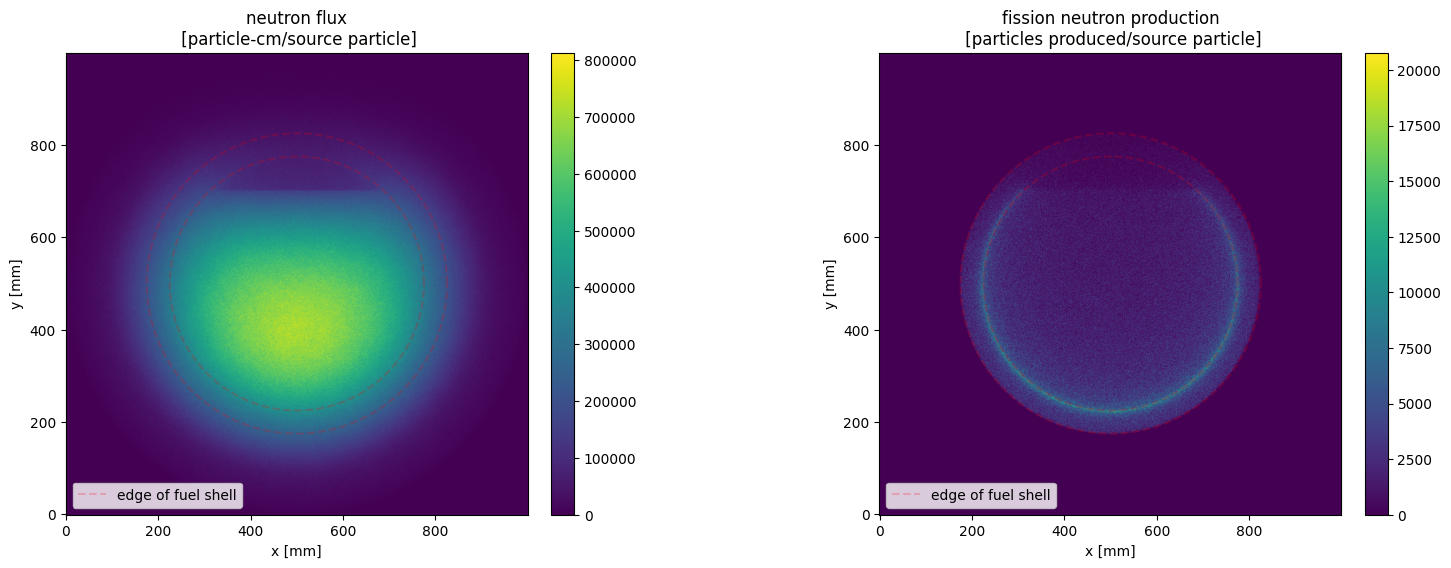

In [11]:
#print(sp.tallies.keys())
def plotCircle(ax ,r ,mesh_size ,resolution, label=False):
    theta = np.linspace(0, 2*np.pi, 200)
    x = (r * np.cos(theta)+mesh_size)*resolution/2
    y = (r * np.sin(theta)+mesh_size)*resolution/2
    if label:
        ax.plot(x,y,'r--',alpha=0.2,label="edge of fuel shell")
    else:
        ax.plot(x,y,'r--',alpha=0.2)
    return (x,y)

with openmc.StatePoint(f'statepoint.{settings_dep.batches}.h5') as sp:
        tally = sp.get_tally(id=1)
        tally1 = sp.get_tally(id=2)

#print(tally)

resolution_of_mesh=10
mesh_size = int(blanket_or)

flux = tally.get_slice(scores=['flux'])
fission = tally.get_slice(scores=['nu-fission'])


flux.std_dev.shape = (mesh_size*resolution_of_mesh, mesh_size*resolution_of_mesh)
flux.mean.shape = (mesh_size*resolution_of_mesh, mesh_size*resolution_of_mesh)
fission.std_dev.shape = (mesh_size*resolution_of_mesh, mesh_size*resolution_of_mesh)
fission.mean.shape = (mesh_size*resolution_of_mesh, mesh_size*resolution_of_mesh)

#Setting up figures using gridspec
fig = plt.figure(figsize=(18,6))
gs = gridspec.GridSpec(1, 2, width_ratios=[1,1], wspace=0.4)



ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])

ax0.set_title("neutron flux\n [particle-cm/source particle]")
im0=ax0.imshow(flux.mean, origin='lower')
plotCircle(ax0, inner_fuel_radius, mesh_size, resolution_of_mesh)
plotCircle(ax0, outer_fuel_radius, mesh_size, resolution_of_mesh, label=True)

ax0.set_xlabel('x [mm]')
ax0.set_ylabel('y [mm]')
fig.colorbar(im0, ax=ax0, fraction=0.046, pad=0.04)
ax0.legend(loc='lower left')

ax1.set_title("fission neutron production\n [particles produced/source particle]")
im1=ax1.imshow(fission.mean, origin='lower')
plotCircle(ax1, inner_fuel_radius, mesh_size, resolution_of_mesh)
plotCircle(ax1, outer_fuel_radius, mesh_size, resolution_of_mesh, label=True)

ax1.set_xlabel('x [mm]')
ax1.set_ylabel('y [mm]')
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
ax1.legend(loc='lower left')


total_fission_n = sum(sum(fission.mean))
print(f'total fission tallied {total_fission_n:.4g}')

In [12]:
'''# Load materials from XML
materials = openmc.Materials.from_xml("materials-finish.xml")

#Using fond  materials 
materials = results.export_to_materials(1)
# Collect all nuclides present
nuclides = []

materials= get_material_by_name("Fuel_CA_2",materials)
for nuclide, amount,_ in mat.nuclides:
    nuclides.append([nuclide,amount])

print(nuclides)'''

'# Load materials from XML\nmaterials = openmc.Materials.from_xml("materials-finish.xml")\n\n#Using fond  materials \nmaterials = results.export_to_materials(1)\n# Collect all nuclides present\nnuclides = []\n\nmaterials= get_material_by_name("Fuel_CA_2",materials)\nfor nuclide, amount,_ in mat.nuclides:\n    nuclides.append([nuclide,amount])\n\nprint(nuclides)'

In [18]:
[print(f'step {s}\t time: {time:.3g}') for s,time in zip(range(nr_steps),timings)]
print('seeing if tallies give same number',fission_tally['mean'].sum(),sum(sum(fission.mean)))

step 0	 time: 7.45e+03
step 1	 time: 8.83e+03
step 2	 time: 9.81e+03
step 3	 time: 1.05e+04
step 4	 time: 1.12e+04
step 5	 time: 8.52e+03
step 6	 time: 9.77e+03
step 7	 time: 7.55e+03
step 8	 time: 8.52e+03
step 9	 time: 5.99e+03
step 10	 time: 6.44e+03
step 11	 time: 5.48e+03
seeing if tallies give same number 10684113009.799553 761179720.0230845


In [ ]:
fission = tally1.get_slice(scores=['nu-fission'])

fission_tally = tally1.get_pandas_dataframe()
#print(fission_tally) 
data_to_file = np.column_stack((fission_tally['energy low [eV]'],fission_tally['mean'],fission_tally['std. dev.']))
np.savetxt(f'fission_tally_{date}_time_{step}_{timestep_units}.csv',data_to_file,delimiter=",",
           header='energy,fission mean,fission std_dev')